# Set up kaggle and download the dataset

In [60]:
!pip install kaggle wandb onnx -Uq
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [62]:
!cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json

In [63]:
! chmod 600 ~/.kaggle/kaggle.json

In [64]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)


In [65]:
! unzip /content/challenges-in-representation-learning-facial-expression-recognition-challenge.zip


Archive:  /content/challenges-in-representation-learning-facial-expression-recognition-challenge.zip
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [66]:
! pip install wandb
! wandb login

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: grtsir22 (grtsir22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Import libraries

In [67]:
import torch
from torch import nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import wandb
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
from torchvision import transforms
import torchvision.models as models





device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU
print("Device available: ", device)

Device available:  cuda


# Load the data

In [68]:
train = pd.read_csv('/content/train.csv')
pixels = train['pixels']
emotion = train['emotion']

In [69]:
print(pixels.shape)
pixels.head()

(28709,)


,pixels
0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,151 150 147 155 148 133 111 140 170 174 182 15...
2,231 212 156 164 174 138 161 173 182 200 106 38...
3,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...


# Let's see a few examples

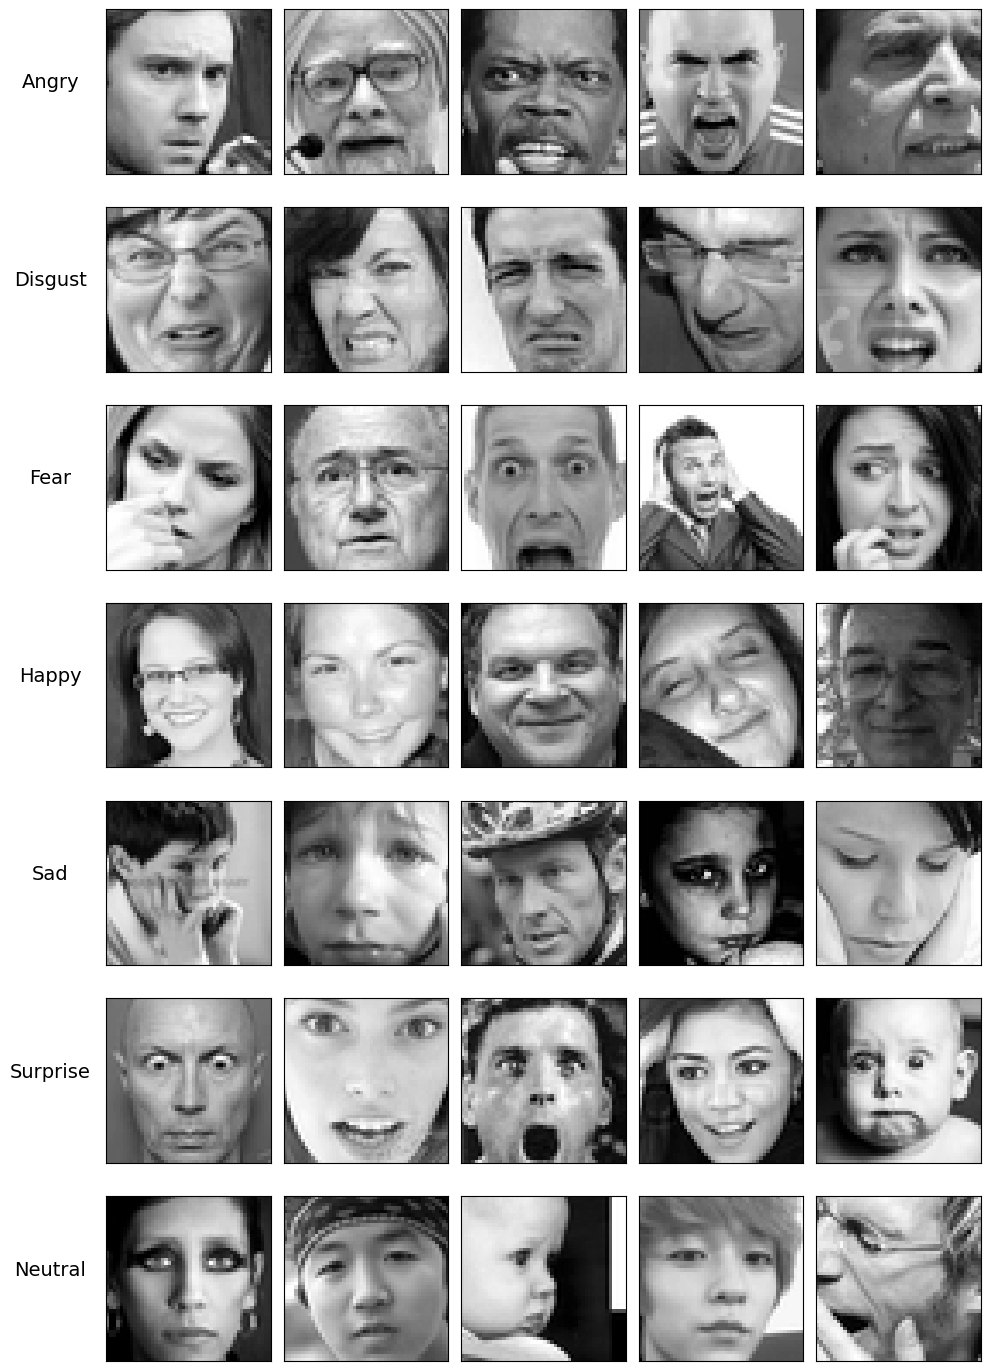

In [70]:
emotion_map = {
    0: 'Angry',
    1: 'Disgust',
    2: 'Fear',
    3: 'Happy',
    4: 'Sad',
    5: 'Surprise',
    6: 'Neutral'
}

examples_per_class = 5

fig, axes = plt.subplots(len(emotion_map), examples_per_class, figsize=(10, 14))

for emotion_idx, emotion_name in emotion_map.items():
    subset_indices = train[train['emotion'] == emotion_idx].index[:examples_per_class]

    for i, idx in enumerate(subset_indices):
        pixel_str = train['pixels'].loc[idx]
        img_array = np.array(pixel_str.split(), dtype='float32').reshape(48, 48)

        ax = axes[emotion_idx, i]
        ax.imshow(img_array, cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])

        if i == 0:
            ax.set_ylabel(emotion_name, fontsize=14, rotation=0, labelpad=40, ha='center')

plt.tight_layout()
plt.show()

# Split the data

In [71]:
X = np.array([np.fromstring(p, dtype='float32', sep=' ') for p in train['pixels']])
X = X.reshape(-1, 48, 48, 1)
X = X / 255.0
y = train['emotion'].values
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")

Training data shape: (22967, 48, 48, 1)
Validation data shape: (5742, 48, 48, 1)


# Dataloader

In [72]:
class FER2013Dataset(Dataset):
    def __init__(self, X, y):
        if len(X.shape) == 4 and X.shape[-1] == 1:
            X = np.transpose(X, (0, 3, 1, 2))

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FER2013Dataset(X_train, y_train)
val_dataset = FER2013Dataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Set up the training and tracking function

In [73]:
def train_model_with_wandb(model, train_loader, val_loader, criterion, optimizer, epochs=25, device='cuda'):
    model = model.to(device)

    print(f"Starting training on {device} with Weights & Biases tracking...")
    print("-" * 50)

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = train_loss / train_total
        epoch_train_acc = (train_correct / train_total) * 100

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / val_total
        epoch_val_acc = (val_correct / val_total) * 100

        # --- WANDB LOGGING ---
        wandb.log({
            "train_loss": epoch_train_loss,
            "train_acc": epoch_train_acc,
            "val_loss": epoch_val_loss,
            "val_acc": epoch_val_acc,
            "overfit_acc": epoch_train_acc - epoch_val_acc,
            "overfit_loss":  epoch_val_loss -   epoch_train_loss
        })

        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.2f}%")
        print(f"  Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.2f}%")
        print("-" * 30)


# **1st Model**

# Set up the neural network

In [78]:
class FaceEmotionCNN_1st(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_1st, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)


        # --- Block 3 ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        # Block 3
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Model summary

In [79]:
model = FaceEmotionCNN_1st(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
            Conv2d-2           [-1, 32, 48, 48]           9,248
         MaxPool2d-3           [-1, 32, 24, 24]               0
            Conv2d-4           [-1, 64, 24, 24]          18,496
            Conv2d-5           [-1, 64, 24, 24]          36,928
         MaxPool2d-6           [-1, 64, 12, 12]               0
           Flatten-7                 [-1, 9216]               0
            Linear-8                  [-1, 128]       1,179,776
            Linear-9                    [-1, 7]             903
Total params: 1,245,671
Trainable params: 1,245,671
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Forward/backward pass size (MB): 1.97
Params size (MB): 4.75
Estimated Total Size (MB): 6.73
---------------------------------------

# Training

In [80]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-small",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_1st(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.6917 | Train Acc: 32.60%
  Val Loss:   1.5475 | Val Acc:   40.35%
------------------------------
Epoch [2/25]
  Train Loss: 1.4648 | Train Acc: 43.82%
  Val Loss:   1.4015 | Val Acc:   46.12%
------------------------------
Epoch [3/25]
  Train Loss: 1.3009 | Train Acc: 50.27%
  Val Loss:   1.2935 | Val Acc:   50.54%
------------------------------
Epoch [4/25]
  Train Loss: 1.1621 | Train Acc: 56.03%
  Val Loss:   1.2779 | Val Acc:   52.02%
------------------------------
Epoch [5/25]
  Train Loss: 1.0255 | Train Acc: 61.46%
  Val Loss:   1.2630 | Val Acc:   51.86%
------------------------------
Epoch [6/25]
  Train Loss: 0.8612 | Train Acc: 68.02%
  Val Loss:   1.3510 | Val Acc:   52.84%
------------------------------
Epoch [7/25]
  Train Loss: 0.6810 | Train Acc: 75.16%
  Val Loss:   1.5320 | Val Acc:   51.45%
-------------------

overfit_acc,▁▂▂▂▃▄▅▆▇▇▇██████████████
overfit_loss,▁▁▁▁▂▂▂▃▄▄▅▅▆▆▆▇▇▇▇▇▇████
train_acc,▁▂▃▃▄▅▆▆▇▇███████████████
train_loss,█▇▆▆▅▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▄▇█▇█▇█▇▇▇▇▇▇▇▇▇▆▇▆▇▇▇▇▇
val_loss,▂▁▁▁▁▁▂▂▃▃▄▅▅▆▆▇▇▇▇▇▇█▇▇█
overfit_acc,47.72286
overfit_loss,4.82712
train_acc,98.62847
train_loss,0.04824
val_acc,50.90561


# **2nd Model**

# Add dropout to the neural network

In [81]:
class FaceEmotionCNN_2nd(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_2nd, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.25)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.25)


        # --- Block 3 ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.drop_fc = nn.Dropout(0.25)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [82]:

model = FaceEmotionCNN_2nd(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
            Conv2d-2           [-1, 32, 48, 48]           9,248
         MaxPool2d-3           [-1, 32, 24, 24]               0
         Dropout2d-4           [-1, 32, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          18,496
            Conv2d-6           [-1, 64, 24, 24]          36,928
         MaxPool2d-7           [-1, 64, 12, 12]               0
         Dropout2d-8           [-1, 64, 12, 12]               0
           Flatten-9                 [-1, 9216]               0
           Linear-10                  [-1, 128]       1,179,776
          Dropout-11                  [-1, 128]               0
           Linear-12                    [-1, 7]             903
Total params: 1,245,671
Trainable params: 1,245,671
Non-trainable params: 0
---------------------------

# Training

In [83]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-with-dropout",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_2nd(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.7694 | Train Acc: 26.76%
  Val Loss:   1.6441 | Val Acc:   34.62%
------------------------------
Epoch [2/25]
  Train Loss: 1.5995 | Train Acc: 37.49%
  Val Loss:   1.5022 | Val Acc:   41.34%
------------------------------
Epoch [3/25]
  Train Loss: 1.4941 | Train Acc: 42.62%
  Val Loss:   1.4277 | Val Acc:   44.24%
------------------------------
Epoch [4/25]
  Train Loss: 1.4178 | Train Acc: 45.31%
  Val Loss:   1.3662 | Val Acc:   46.99%
------------------------------
Epoch [5/25]
  Train Loss: 1.3502 | Train Acc: 48.01%
  Val Loss:   1.3178 | Val Acc:   49.27%
------------------------------
Epoch [6/25]
  Train Loss: 1.2854 | Train Acc: 50.46%
  Val Loss:   1.2749 | Val Acc:   51.50%
------------------------------
Epoch [7/25]
  Train Loss: 1.2364 | Train Acc: 52.78%
  Val Loss:   1.2431 | Val Acc:   52.79%
-------------------

overfit_acc,▁▂▂▂▃▃▃▃▄▄▅▅▅▆▆▆▇▇▇▇▇████
overfit_loss,▁▁▁▂▂▂▂▂▃▃▃▄▄▅▅▅▆▆▆▆▇████
train_acc,▁▂▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,█▇▆▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▃▄▅▆▇▇▇▇▇▇█████▇████████
val_loss,█▆▄▃▃▂▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▅▄▅▅
overfit_acc,22.3214
overfit_loss,0.86366
train_acc,77.85954
train_loss,0.58112
val_acc,55.53814


# **3rd Model**

# Let's try a stronger dropout

In [84]:
class FaceEmotionCNN_3rd(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_3rd, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)


        # --- Block 3 ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [85]:
model = FaceEmotionCNN_3rd(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
            Conv2d-2           [-1, 32, 48, 48]           9,248
         MaxPool2d-3           [-1, 32, 24, 24]               0
         Dropout2d-4           [-1, 32, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          18,496
            Conv2d-6           [-1, 64, 24, 24]          36,928
         MaxPool2d-7           [-1, 64, 12, 12]               0
         Dropout2d-8           [-1, 64, 12, 12]               0
           Flatten-9                 [-1, 9216]               0
           Linear-10                  [-1, 128]       1,179,776
          Dropout-11                  [-1, 128]               0
           Linear-12                    [-1, 7]             903
Total params: 1,245,671
Trainable params: 1,245,671
Non-trainable params: 0
---------------------------

# Training

In [86]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-with-strong-dropout",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_3rd(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.8244 | Train Acc: 24.46%
  Val Loss:   1.7870 | Val Acc:   25.57%
------------------------------
Epoch [2/25]
  Train Loss: 1.7520 | Train Acc: 28.55%
  Val Loss:   1.6743 | Val Acc:   31.07%
------------------------------
Epoch [3/25]
  Train Loss: 1.6783 | Train Acc: 33.38%
  Val Loss:   1.5761 | Val Acc:   38.38%
------------------------------
Epoch [4/25]
  Train Loss: 1.6066 | Train Acc: 36.81%
  Val Loss:   1.4983 | Val Acc:   41.88%
------------------------------
Epoch [5/25]
  Train Loss: 1.5506 | Train Acc: 39.40%
  Val Loss:   1.4648 | Val Acc:   43.03%
------------------------------
Epoch [6/25]
  Train Loss: 1.5070 | Train Acc: 41.36%
  Val Loss:   1.4215 | Val Acc:   45.16%
------------------------------
Epoch [7/25]
  Train Loss: 1.4725 | Train Acc: 42.72%
  Val Loss:   1.3734 | Val Acc:   46.83%
-------------------

overfit_acc,▅▃▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▆▆▆▇▇█
overfit_loss,▄▂▁▁▂▂▁▂▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇▇█
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇██████
train_loss,█▇▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▂▄▅▅▆▆▇▇▇▇▇▇████████████
val_loss,█▇▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
overfit_acc,2.31431
overfit_loss,0.07114
train_acc,55.17046
train_loss,1.1555
val_acc,52.85615


# **4th Model**

# Let's add another block

In [87]:
class FaceEmotionCNN_4th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_4th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(0.5)


        # --- Block 4  ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.drop3(self.pool3(x))

        # Block 4
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [88]:
model = FaceEmotionCNN_4th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
            Conv2d-2           [-1, 32, 48, 48]           9,248
         MaxPool2d-3           [-1, 32, 24, 24]               0
         Dropout2d-4           [-1, 32, 24, 24]               0
            Conv2d-5           [-1, 64, 24, 24]          18,496
            Conv2d-6           [-1, 64, 24, 24]          36,928
         MaxPool2d-7           [-1, 64, 12, 12]               0
         Dropout2d-8           [-1, 64, 12, 12]               0
            Conv2d-9          [-1, 128, 12, 12]          73,856
           Conv2d-10          [-1, 128, 12, 12]         147,584
        MaxPool2d-11            [-1, 128, 6, 6]               0
        Dropout2d-12            [-1, 128, 6, 6]               0
          Flatten-13                 [-1, 4608]               0
           Linear-14                  [

# Training

In [89]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-more-complex",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_4th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.8253 | Train Acc: 24.64%
  Val Loss:   1.8103 | Val Acc:   25.13%
------------------------------
Epoch [2/25]
  Train Loss: 1.8149 | Train Acc: 25.16%
  Val Loss:   1.7936 | Val Acc:   25.30%
------------------------------
Epoch [3/25]
  Train Loss: 1.7996 | Train Acc: 25.02%
  Val Loss:   1.7817 | Val Acc:   25.13%
------------------------------
Epoch [4/25]
  Train Loss: 1.7768 | Train Acc: 25.82%
  Val Loss:   1.7154 | Val Acc:   30.86%
------------------------------
Epoch [5/25]
  Train Loss: 1.7255 | Train Acc: 29.75%
  Val Loss:   1.6768 | Val Acc:   31.77%
------------------------------
Epoch [6/25]
  Train Loss: 1.6699 | Train Acc: 33.68%
  Val Loss:   1.6078 | Val Acc:   35.81%
------------------------------
Epoch [7/25]
  Train Loss: 1.6131 | Train Acc: 36.67%
  Val Loss:   1.5577 | Val Acc:   38.51%
-------------------

overfit_acc,▇██▁▅▅▆▃▄▃▄▄▅▃▅▄▄▆▄▅▆▅▆▆▆
overfit_loss,█▇█▂▄▂▃▁▃▁▃▃▃▃▄▃▃▄▃▄▅▅▇▅▇
train_acc,▁▁▁▁▂▃▄▅▅▅▆▆▆▆▇▇▇▇▇▇█████
train_loss,███▇▇▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▁▁▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇███████
val_loss,███▇▆▅▅▄▄▃▃▃▃▂▂▂▂▂▁▂▁▁▁▁▁
overfit_acc,-1.46508
overfit_loss,-0.01932
train_acc,50.11974
train_loss,1.2875
val_acc,51.58481


# **5th model**

# Let's add batch normalization

In [90]:
class FaceEmotionCNN_5th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_5th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(0.5)


        # --- Block 4  ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(self.pool3(x))

        # Block 4
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [91]:
model = FaceEmotionCNN_5th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
            Conv2d-3           [-1, 32, 48, 48]           9,248
       BatchNorm2d-4           [-1, 32, 48, 48]              64
         MaxPool2d-5           [-1, 32, 24, 24]               0
         Dropout2d-6           [-1, 32, 24, 24]               0
            Conv2d-7           [-1, 64, 24, 24]          18,496
       BatchNorm2d-8           [-1, 64, 24, 24]             128
            Conv2d-9           [-1, 64, 24, 24]          36,928
      BatchNorm2d-10           [-1, 64, 24, 24]             128
        MaxPool2d-11           [-1, 64, 12, 12]               0
        Dropout2d-12           [-1, 64, 12, 12]               0
           Conv2d-13          [-1, 128, 12, 12]          73,856
      BatchNorm2d-14          [-1, 128,

# Training

In [92]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-batch-norm",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_5th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.7920 | Train Acc: 26.87%
  Val Loss:   1.6124 | Val Acc:   37.03%
------------------------------
Epoch [2/25]
  Train Loss: 1.5885 | Train Acc: 37.33%
  Val Loss:   1.4532 | Val Acc:   43.90%
------------------------------
Epoch [3/25]
  Train Loss: 1.4848 | Train Acc: 42.37%
  Val Loss:   1.3485 | Val Acc:   48.28%
------------------------------
Epoch [4/25]
  Train Loss: 1.4091 | Train Acc: 45.14%
  Val Loss:   1.2860 | Val Acc:   50.78%
------------------------------
Epoch [5/25]
  Train Loss: 1.3575 | Train Acc: 47.68%
  Val Loss:   1.2397 | Val Acc:   52.59%
------------------------------
Epoch [6/25]
  Train Loss: 1.3218 | Train Acc: 49.35%
  Val Loss:   1.2048 | Val Acc:   53.61%
------------------------------
Epoch [7/25]
  Train Loss: 1.2873 | Train Acc: 50.64%
  Val Loss:   1.1797 | Val Acc:   55.19%
-------------------

overfit_acc,▁▃▃▄▄▄▄▅▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇█
overfit_loss,▁▂▂▃▃▃▃▄▃▄▄▄▄▄▅▅▅▆▆▆▆▇▇▇█
train_acc,▁▃▄▄▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▅▆▆▆▆▆▇▇▇▇▇▇█████████
val_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
overfit_acc,2.17101
overfit_loss,0.06747
train_acc,63.66526
train_loss,0.96135
val_acc,61.49425


# **6th Model**

# Let's increase complexity further

In [93]:
class FaceEmotionCNN_6th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_6th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.drop3 = nn.Dropout2d(0.5)


        # --- Block 4 ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 12 * 12, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(x)

        # Block 4
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [94]:
model = FaceEmotionCNN_6th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
            Conv2d-3           [-1, 32, 48, 48]           9,248
       BatchNorm2d-4           [-1, 32, 48, 48]              64
         MaxPool2d-5           [-1, 32, 24, 24]               0
         Dropout2d-6           [-1, 32, 24, 24]               0
            Conv2d-7           [-1, 64, 24, 24]          18,496
       BatchNorm2d-8           [-1, 64, 24, 24]             128
            Conv2d-9           [-1, 64, 24, 24]          36,928
      BatchNorm2d-10           [-1, 64, 24, 24]             128
        MaxPool2d-11           [-1, 64, 12, 12]               0
        Dropout2d-12           [-1, 64, 12, 12]               0
           Conv2d-13          [-1, 128, 12, 12]          73,856
      BatchNorm2d-14          [-1, 128,

# Training

In [95]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-less-pooling",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_6th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.7965 | Train Acc: 27.08%
  Val Loss:   1.5640 | Val Acc:   39.41%
------------------------------
Epoch [2/25]
  Train Loss: 1.5623 | Train Acc: 39.10%
  Val Loss:   1.4513 | Val Acc:   43.78%
------------------------------
Epoch [3/25]
  Train Loss: 1.4594 | Train Acc: 43.53%
  Val Loss:   1.4003 | Val Acc:   46.41%
------------------------------
Epoch [4/25]
  Train Loss: 1.3976 | Train Acc: 45.77%
  Val Loss:   1.2954 | Val Acc:   49.88%
------------------------------
Epoch [5/25]
  Train Loss: 1.3444 | Train Acc: 48.26%
  Val Loss:   1.2577 | Val Acc:   51.53%
------------------------------
Epoch [6/25]
  Train Loss: 1.3090 | Train Acc: 49.38%
  Val Loss:   1.2189 | Val Acc:   53.31%
------------------------------
Epoch [7/25]
  Train Loss: 1.2767 | Train Acc: 50.72%
  Val Loss:   1.1977 | Val Acc:   53.90%
-------------------

overfit_acc,▁▃▄▃▄▃▄▄▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
overfit_loss,▁▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▇▇██
train_acc,▁▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
val_acc,▁▂▃▄▅▆▆▆▇▇▇▇▇▇▇▇█████████
val_loss,█▆▆▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▂▂▂
overfit_acc,11.31887
overfit_loss,0.37531
train_acc,71.90752
train_loss,0.74845
val_acc,60.58865


# **7th Model**

# Let's increase the dropout

In [96]:
class FaceEmotionCNN_7th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_7th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.drop3 = nn.Dropout2d(0.55)


        # --- Block 4 ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 12 * 12, 256)
        self.bn_fc = nn.BatchNorm1d(256)
        self.drop_fc = nn.Dropout(0.65)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(x)

        # Block 4
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [97]:
model = FaceEmotionCNN_7th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
            Conv2d-3           [-1, 32, 48, 48]           9,248
       BatchNorm2d-4           [-1, 32, 48, 48]              64
         MaxPool2d-5           [-1, 32, 24, 24]               0
         Dropout2d-6           [-1, 32, 24, 24]               0
            Conv2d-7           [-1, 64, 24, 24]          18,496
       BatchNorm2d-8           [-1, 64, 24, 24]             128
            Conv2d-9           [-1, 64, 24, 24]          36,928
      BatchNorm2d-10           [-1, 64, 24, 24]             128
        MaxPool2d-11           [-1, 64, 12, 12]               0
        Dropout2d-12           [-1, 64, 12, 12]               0
           Conv2d-13          [-1, 128, 12, 12]          73,856
      BatchNorm2d-14          [-1, 128,

# Training

In [98]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-extreme-dropout",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_7th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.8253 | Train Acc: 26.27%
  Val Loss:   1.6520 | Val Acc:   33.94%
------------------------------
Epoch [2/25]
  Train Loss: 1.6309 | Train Acc: 35.56%
  Val Loss:   1.5080 | Val Acc:   40.87%
------------------------------
Epoch [3/25]
  Train Loss: 1.5301 | Train Acc: 40.31%
  Val Loss:   1.4191 | Val Acc:   44.71%
------------------------------
Epoch [4/25]
  Train Loss: 1.4729 | Train Acc: 42.70%
  Val Loss:   1.3416 | Val Acc:   47.91%
------------------------------
Epoch [5/25]
  Train Loss: 1.4136 | Train Acc: 45.10%
  Val Loss:   1.3001 | Val Acc:   49.44%
------------------------------
Epoch [6/25]
  Train Loss: 1.3817 | Train Acc: 46.72%
  Val Loss:   1.2538 | Val Acc:   51.27%
------------------------------
Epoch [7/25]
  Train Loss: 1.3478 | Train Acc: 48.01%
  Val Loss:   1.2415 | Val Acc:   52.47%
-------------------

overfit_acc,▁▃▃▃▃▃▃▄▄▃▄▄▄▄▅▅▆▅▆▆▆▇███
overfit_loss,▁▂▃▂▃▂▃▃▃▃▃▃▄▄▄▄▅▅▅▆▆▇▇▇█
train_acc,▁▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇████
train_loss,█▆▆▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▅▅▆▆▆▇▇▇▇▇▇▇▇████████
val_loss,█▆▅▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
overfit_acc,1.68768
overfit_loss,0.06583
train_acc,62.71172
train_loss,0.9813
val_acc,61.02403


# **8th Model**

# Let's keep the pooling add a new block instead

In [99]:
class FaceEmotionCNN_8th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_8th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.5)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.5)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(0.5)

        # --- Block 4 ---
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop4 = nn.Dropout2d(0.5)


        # --- Block 5  ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 3 * 3, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(self.pool3(x))

        # Block 4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.drop4(self.pool4(x))

        # Block 5
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [100]:
model = FaceEmotionCNN_8th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
            Conv2d-3           [-1, 32, 48, 48]           9,248
       BatchNorm2d-4           [-1, 32, 48, 48]              64
         MaxPool2d-5           [-1, 32, 24, 24]               0
         Dropout2d-6           [-1, 32, 24, 24]               0
            Conv2d-7           [-1, 64, 24, 24]          18,496
       BatchNorm2d-8           [-1, 64, 24, 24]             128
            Conv2d-9           [-1, 64, 24, 24]          36,928
      BatchNorm2d-10           [-1, 64, 24, 24]             128
        MaxPool2d-11           [-1, 64, 12, 12]               0
        Dropout2d-12           [-1, 64, 12, 12]               0
           Conv2d-13          [-1, 128, 12, 12]          73,856
      BatchNorm2d-14          [-1, 128,

# Training

In [101]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-5-blocks",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_8th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.8730 | Train Acc: 23.19%
  Val Loss:   1.7968 | Val Acc:   24.85%
------------------------------
Epoch [2/25]
  Train Loss: 1.8283 | Train Acc: 24.02%
  Val Loss:   1.7800 | Val Acc:   25.48%
------------------------------
Epoch [3/25]
  Train Loss: 1.8069 | Train Acc: 25.34%
  Val Loss:   1.7414 | Val Acc:   28.28%
------------------------------
Epoch [4/25]
  Train Loss: 1.7195 | Train Acc: 31.52%
  Val Loss:   1.5765 | Val Acc:   38.40%
------------------------------
Epoch [5/25]
  Train Loss: 1.6001 | Train Acc: 37.03%
  Val Loss:   1.4812 | Val Acc:   42.18%
------------------------------
Epoch [6/25]
  Train Loss: 1.5179 | Train Acc: 40.60%
  Val Loss:   1.4155 | Val Acc:   44.97%
------------------------------
Epoch [7/25]
  Train Loss: 1.4608 | Train Acc: 42.87%
  Val Loss:   1.3394 | Val Acc:   47.98%
-------------------

overfit_acc,▆▆▅▁▃▃▃▄▄▅▅▄▅▆▅▆▆▆▇▆▆████
overfit_loss,▄▅▄▁▂▃▂▂▃▃▃▃▄▄▄▄▅▅▆▆▆▇▇██
train_acc,▁▁▁▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,██▇▇▆▅▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▁▂▄▄▅▆▆▆▆▇▇▇▇▇▇▇▇███████
val_loss,██▇▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁
overfit_acc,0.22906
overfit_loss,0.02602
train_acc,60.97444
train_loss,1.02628
val_acc,60.74538


# **9th Model**

# Relax dropout and drop the last maxpool

In [102]:
class FaceEmotionCNN_9th(nn.Module):
    def __init__(self, num_classes=7):
        super(FaceEmotionCNN_9th, self).__init__()

        # --- Block 1 ---
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop1 = nn.Dropout2d(0.15)


        # --- Block 2 ---
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop2 = nn.Dropout2d(0.25)

        # --- Block 3 ---
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.drop3 = nn.Dropout2d(0.35)

        # --- Block 4 ---
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(256)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(256)
        self.drop4 = nn.Dropout2d(0.45)


        # --- Block 5  ---
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.bn_fc = nn.BatchNorm1d(512)
        self.drop_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.drop3(self.pool3(x))

        # Block 4
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.drop4(x)

        # Block 5
        x = self.flatten(x)
        x = F.relu(self.bn_fc(self.fc1(x)))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

# Model summary

In [103]:
model = FaceEmotionCNN_9th(num_classes=7).to(device)
summary(model, input_size=(1, 48, 48))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 48, 48]             320
       BatchNorm2d-2           [-1, 32, 48, 48]              64
            Conv2d-3           [-1, 32, 48, 48]           9,248
       BatchNorm2d-4           [-1, 32, 48, 48]              64
         MaxPool2d-5           [-1, 32, 24, 24]               0
         Dropout2d-6           [-1, 32, 24, 24]               0
            Conv2d-7           [-1, 64, 24, 24]          18,496
       BatchNorm2d-8           [-1, 64, 24, 24]             128
            Conv2d-9           [-1, 64, 24, 24]          36,928
      BatchNorm2d-10           [-1, 64, 24, 24]             128
        MaxPool2d-11           [-1, 64, 12, 12]               0
        Dropout2d-12           [-1, 64, 12, 12]               0
           Conv2d-13          [-1, 128, 12, 12]          73,856
      BatchNorm2d-14          [-1, 128,

# Training

In [104]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-5-blocks-relaxed",
        "dataset": "FER2013",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_9th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.7906 | Train Acc: 27.46%
  Val Loss:   1.5933 | Val Acc:   36.83%
------------------------------
Epoch [2/25]
  Train Loss: 1.5343 | Train Acc: 39.49%
  Val Loss:   1.3927 | Val Acc:   45.33%
------------------------------
Epoch [3/25]
  Train Loss: 1.3695 | Train Acc: 46.50%
  Val Loss:   1.2437 | Val Acc:   51.43%
------------------------------
Epoch [4/25]
  Train Loss: 1.2812 | Train Acc: 50.22%
  Val Loss:   1.1926 | Val Acc:   53.66%
------------------------------
Epoch [5/25]
  Train Loss: 1.2202 | Train Acc: 53.14%
  Val Loss:   1.1646 | Val Acc:   55.26%
------------------------------
Epoch [6/25]
  Train Loss: 1.1750 | Train Acc: 54.88%
  Val Loss:   1.1179 | Val Acc:   57.56%
------------------------------
Epoch [7/25]
  Train Loss: 1.1312 | Train Acc: 56.68%
  Val Loss:   1.0942 | Val Acc:   58.25%
-------------------

overfit_acc,▁▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇██
overfit_loss,▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▆▆▆▇▇██
train_acc,▁▃▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train_loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▃▅▅▆▆▇▇▇▇▇▇█████████████
val_loss,█▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▂▁▂▂▂▃▃
overfit_acc,14.78485
overfit_loss,0.59014
train_acc,78.35155
train_loss,0.58036
val_acc,63.5667


# **Data augmentation**

In [105]:
class FER2013DatasetAugmented(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = (self.X[idx] * 255).astype(np.uint8)
        img = Image.fromarray(img.squeeze(), mode='L')

        if self.transform:
            img = self.transform(img)
        else:
            img = transforms.ToTensor()(img)

        return img, self.y[idx]

In [106]:
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])

val_transforms = transforms.Compose([
    transforms.ToTensor()
])

train_dataset_aug = FER2013DatasetAugmented(X_train, y_train, transform=train_transforms)
val_dataset_aug = FER2013DatasetAugmented(X_val, y_val, transform=val_transforms)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=64, shuffle=False)

# Train the same model with augmented data

In [107]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-5-blocks-relaxed",
        "dataset": "FER2013-augmented",
        "epochs": 25,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_9th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------


/tmp/ipykernel_1642/3833360637.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img.squeeze(), mode='L') # 'L' is grayscale mode


Epoch [1/25]
  Train Loss: 1.8539 | Train Acc: 23.76%
  Val Loss:   1.7796 | Val Acc:   26.59%
------------------------------
Epoch [2/25]
  Train Loss: 1.8112 | Train Acc: 25.87%
  Val Loss:   1.7169 | Val Acc:   31.23%
------------------------------
Epoch [3/25]
  Train Loss: 1.6501 | Train Acc: 34.13%
  Val Loss:   1.4516 | Val Acc:   43.42%
------------------------------
Epoch [4/25]
  Train Loss: 1.5116 | Train Acc: 40.80%
  Val Loss:   1.3162 | Val Acc:   48.33%
------------------------------
Epoch [5/25]
  Train Loss: 1.4069 | Train Acc: 45.29%
  Val Loss:   1.2663 | Val Acc:   51.34%
------------------------------
Epoch [6/25]
  Train Loss: 1.3610 | Train Acc: 47.09%
  Val Loss:   1.2559 | Val Acc:   51.25%
------------------------------
Epoch [7/25]
  Train Loss: 1.3220 | Train Acc: 48.57%
  Val Loss:   1.2027 | Val Acc:   53.55%
------------------------------
Epoch [8/25]
  Train Loss: 1.2894 | Train Acc: 50.32%
  Val Loss:   1.1610 | Val Acc:   54.88%
-----------------------

overfit_acc,█▅▁▃▅▇▆▆▆▆▇▆▆▇▆▆▆▇▇▇█▆█▇█
overfit_loss,█▇▁▁▄▆▅▅▅▅▆▄▅▅▄▅▅▆▆▅▆▅▇▆▇
train_acc,▁▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇████████
train_loss,██▆▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▂▄▅▆▆▆▆▇▇▇▇▇▇███████████
val_loss,█▇▅▄▃▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁
overfit_acc,-2.83616
overfit_loss,-0.09293
train_acc,59.12831
train_loss,1.07604
val_acc,61.96447


# **Train again for longer**

In [108]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "CNN-5-blocks-relaxed",
        "dataset": "FER2013-augmented",
        "epochs": 100,
        "batch_size": 64,
        "optimizer": "Adam"
    }
)

config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = FaceEmotionCNN_9th(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_model_with_wandb(
    model=model,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Using device: cuda
Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------


/tmp/ipykernel_1642/3833360637.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img.squeeze(), mode='L') # 'L' is grayscale mode


Epoch [1/100]
  Train Loss: 1.8666 | Train Acc: 23.09%
  Val Loss:   1.7777 | Val Acc:   26.05%
------------------------------
Epoch [2/100]
  Train Loss: 1.8138 | Train Acc: 24.98%
  Val Loss:   1.7564 | Val Acc:   26.82%
------------------------------
Epoch [3/100]
  Train Loss: 1.7436 | Train Acc: 29.66%
  Val Loss:   1.5826 | Val Acc:   37.16%
------------------------------
Epoch [4/100]
  Train Loss: 1.5518 | Train Acc: 39.32%
  Val Loss:   1.4008 | Val Acc:   45.05%
------------------------------
Epoch [5/100]
  Train Loss: 1.4478 | Train Acc: 43.44%
  Val Loss:   1.2873 | Val Acc:   49.09%
------------------------------
Epoch [6/100]
  Train Loss: 1.3827 | Train Acc: 46.31%
  Val Loss:   1.2594 | Val Acc:   51.53%
------------------------------
Epoch [7/100]
  Train Loss: 1.3441 | Train Acc: 48.04%
  Val Loss:   1.2093 | Val Acc:   53.38%
------------------------------
Epoch [8/100]
  Train Loss: 1.3057 | Train Acc: 49.54%
  Val Loss:   1.1842 | Val Acc:   53.64%
---------------

overfit_acc,▁▃▃▃▄▅▄▄▄▄▅▄▅▅▅▆▅▅▆▅▆▅▆▆▆▆▆▆▆▆▇▇██▇██▇██
overfit_loss,▁▁▁▂▂▄▄▃▃▂▃▄▃▄▃▄▄▄▄▅▄▄▅▅▅▅▆▅▆▆▇▇▇▇▇█████
train_acc,▁▂▃▃▃▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████████
train_loss,█▆▆▅▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▆▆▆▇▇▇▇▇▇▇▇▇▇▇████████████████████████
val_loss,█▅▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
overfit_acc,0.54284
overfit_loss,0.02239
train_acc,68.04546
train_loss,0.85553
val_acc,67.50261


# **ResNet**

In [109]:
class FERResNet18(nn.Module):
    def __init__(self, num_classes=7):
        super(FERResNet18, self).__init__()
        self.resnet = models.resnet18(weights=None)

        self.resnet.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.resnet.maxpool = nn.Identity()

        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(num_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

In [112]:
import wandb

wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "ResNet18-Modified",
        "batch_size": 64,
        "epochs": 25,
        "optimizer": "Adam"
    }
)
config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FERResNet18(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.5220 | Train Acc: 40.61%
  Val Loss:   1.3604 | Val Acc:   48.35%
------------------------------
Epoch [2/25]
  Train Loss: 1.2391 | Train Acc: 52.71%
  Val Loss:   1.3921 | Val Acc:   47.89%
------------------------------
Epoch [3/25]
  Train Loss: 1.1065 | Train Acc: 58.16%
  Val Loss:   1.2969 | Val Acc:   50.49%
------------------------------
Epoch [4/25]
  Train Loss: 0.9947 | Train Acc: 62.83%
  Val Loss:   1.1873 | Val Acc:   56.62%
------------------------------
Epoch [5/25]
  Train Loss: 0.8909 | Train Acc: 66.81%
  Val Loss:   1.0819 | Val Acc:   59.84%
------------------------------
Epoch [6/25]
  Train Loss: 0.7639 | Train Acc: 71.48%
  Val Loss:   1.2585 | Val Acc:   55.36%
------------------------------
Epoch [7/25]
  Train Loss: 0.6050 | Train Acc: 77.80%
  Val Loss:   1.2094 | Val Acc:   59.20%
------------------------------
Epoch [

overfit_acc,▁▃▃▃▃▄▅▆▇█▇██████████████
overfit_loss,▁▂▂▂▂▃▃▄▅▆▆▆▆▆▇▇▇▇█▇▇▇▇██
train_acc,▁▂▃▄▄▅▅▆▇▇███████████████
train_loss,█▇▆▆▅▄▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▂▆█▅▇▇▅▅▇▇▇▇▇▇▇█▇▇▇▆▇█▇
val_loss,▂▂▂▁▁▂▂▂▃▅▅▆▅▅▆▆▆▆█▇▇▆▇▇█
overfit_acc,39.04554
overfit_loss,2.79715
train_acc,98.01454
train_loss,0.05832
val_acc,58.969


# Let's add dropout

In [113]:
class FERResNet18_dropout(nn.Module):
    def __init__(self, num_classes=7):
        super(FERResNet18_dropout, self).__init__()
        self.resnet = models.resnet18(weights=None)

        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()

        num_features = self.resnet.fc.in_features

        self.resnet.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(num_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)

In [114]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.001,
        "architecture": "ResNet18-with-dropout",
        "batch_size": 64,
        "epochs": 25,
        "optimizer": "Adam"
    }
)
config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FERResNet18_dropout(num_classes=7).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.7133 | Train Acc: 32.51%
  Val Loss:   1.4908 | Val Acc:   43.30%
------------------------------
Epoch [2/25]
  Train Loss: 1.3545 | Train Acc: 48.18%
  Val Loss:   1.3372 | Val Acc:   47.96%
------------------------------
Epoch [3/25]
  Train Loss: 1.2185 | Train Acc: 53.55%
  Val Loss:   1.2074 | Val Acc:   54.13%
------------------------------
Epoch [4/25]
  Train Loss: 1.1223 | Train Acc: 57.70%
  Val Loss:   1.1178 | Val Acc:   57.80%
------------------------------
Epoch [5/25]
  Train Loss: 1.0351 | Train Acc: 60.95%
  Val Loss:   1.1810 | Val Acc:   56.48%
------------------------------
Epoch [6/25]
  Train Loss: 0.9501 | Train Acc: 64.64%
  Val Loss:   1.0977 | Val Acc:   57.80%
------------------------------
Epoch [7/25]
  Train Loss: 0.8626 | Train Acc: 67.96%
  Val Loss:   1.2016 | Val Acc:   57.80%
------------------------------
Epoch [

overfit_acc,▁▃▂▂▃▃▄▅▅▆▇▇█████████████
overfit_loss,▁▁▁▁▂▂▂▃▃▄▅▅▆▆▆▆▆▆▆▇▇▇▇█▇
train_acc,▁▃▃▄▄▄▅▅▆▆▇▇█████████████
train_loss,█▆▆▆▅▅▄▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▅▇▆▇▇▆▇▇▇█▇▇██▇▇▇▇▇▇█▇█
val_loss,▂▂▁▁▁▁▁▂▂▂▄▄▅▄▅▅▆▅▅▇▇▆▆█▆
overfit_acc,37.97449
overfit_loss,2.38513
train_acc,98.12775
train_loss,0.05593
val_acc,60.15326


# **MobileNet**

In [115]:
class FERMobileNetV2(nn.Module):
    def __init__(self, num_classes=7, dropout_rate=0.5):
        super(FERMobileNetV2, self).__init__()
        self.mobilenet = models.mobilenet_v2(weights=None)

        self.mobilenet.features[0][0] = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )


        in_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.mobilenet(x)

In [116]:
wandb.init(
    project="fer2013-facial-expression",
    config={
        "learning_rate": 0.0005,
        "architecture": "MobileNetV2-Modified",
        "batch_size": 64,
        "epochs": 25,
        "weight_decay": 1e-4,
        "optimizer": "Adam"
    }
)
config = wandb.config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FERMobileNetV2(num_classes=7, dropout_rate=0.5).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=config.learning_rate,
    weight_decay=config.weight_decay
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

train_model_with_wandb(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=config.epochs,
    device=device
)

wandb.finish()

Starting training on cuda with Weights & Biases tracking...
--------------------------------------------------
Epoch [1/25]
  Train Loss: 1.8154 | Train Acc: 24.44%
  Val Loss:   1.7461 | Val Acc:   28.58%
------------------------------
Epoch [2/25]
  Train Loss: 1.6959 | Train Acc: 31.47%
  Val Loss:   1.6440 | Val Acc:   34.20%
------------------------------
Epoch [3/25]
  Train Loss: 1.5450 | Train Acc: 39.88%
  Val Loss:   1.5150 | Val Acc:   40.96%
------------------------------
Epoch [4/25]
  Train Loss: 1.4355 | Train Acc: 44.75%
  Val Loss:   1.4502 | Val Acc:   43.78%
------------------------------
Epoch [5/25]
  Train Loss: 1.3330 | Train Acc: 49.32%
  Val Loss:   1.4132 | Val Acc:   45.45%
------------------------------
Epoch [6/25]
  Train Loss: 1.2432 | Train Acc: 52.74%
  Val Loss:   1.3960 | Val Acc:   45.58%
------------------------------
Epoch [7/25]
  Train Loss: 1.1582 | Train Acc: 56.22%
  Val Loss:   1.3681 | Val Acc:   49.34%
------------------------------
Epoch [

overfit_acc,▁▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇█▇█████
overfit_loss,▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▆▆▆▇▇▇▇█▇█
train_acc,▁▂▃▃▄▄▄▅▅▅▆▆▆▇▇▇▇▇███████
train_loss,█▇▇▆▆▅▅▅▄▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁
val_acc,▁▃▅▆▆▆▇▇████▇█▇█▇█▇█▇████
val_loss,▄▃▂▂▁▁▁▁▁▁▂▂▂▃▄▄▅▅▆▆▇▆▇▇█
overfit_acc,42.33684
overfit_loss,2.06725
train_acc,92.47616
train_loss,0.22001
val_acc,50.13932
